# Credit Scoring Model — CodeAlpha Internship
**Name:** Sara   
**Task:** Loan Prediction using ML  
**Dataset:** Kaggle — sohailaelsayed/loan-prediction  
**Models:** Logistic Regression, Decision Tree, Random Forest

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.impute           import SimpleImputer

from sklearn.linear_model    import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)


In [2]:
from google.colab import files
uploaded = files.upload()


Saving loan_data.csv to loan_data.csv


In [3]:
df = pd.read_csv('loan_data.csv')

In [4]:
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
df.head()

Shape: (45000, 14)

Columns:
['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
print("── Data Types ──")
print(df.dtypes)

print("\n── Missing Values (count & %) ──")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, '%': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

print("\n── Target Distribution ──")
print(df['loan_status'].value_counts())
print(df['loan_status'].value_counts(normalize=True).round(3) * 100, "%")

print("\n── Numerical Summary ──")
df.describe().round(2)

── Data Types ──
person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

── Missing Values (count & %) ──
Empty DataFrame
Columns: [Missing, %]
Index: []

── Target Distribution ──
loan_status
0    35000
1    10000
Name: count, dtype: int64
loan_status
0    77.8
1    22.2
Name: proportion, dtype: float64 %

── Numerical Summary ──


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00
mean,27.76,80319.05,5.41,9583.16,11.01,0.14,5.87,632.61,0.22
std,6.05,80422.50,6.06,6314.89,2.98,0.09,3.88,50.44,0.42
min,20.00,8000.00,0.00,500.00,5.42,0.00,2.00,390.00,0.00
25%,24.00,47204.00,1.00,5000.00,8.59,0.07,3.00,601.00,0.00
50%,26.00,67048.00,4.00,8000.00,11.01,0.12,4.00,640.00,0.00
75%,30.00,95789.25,8.00,12237.25,12.99,0.19,8.00,670.00,0.00
max,144.00,7200766.00,125.00,35000.00,20.00,0.66,30.00,850.00,1.00


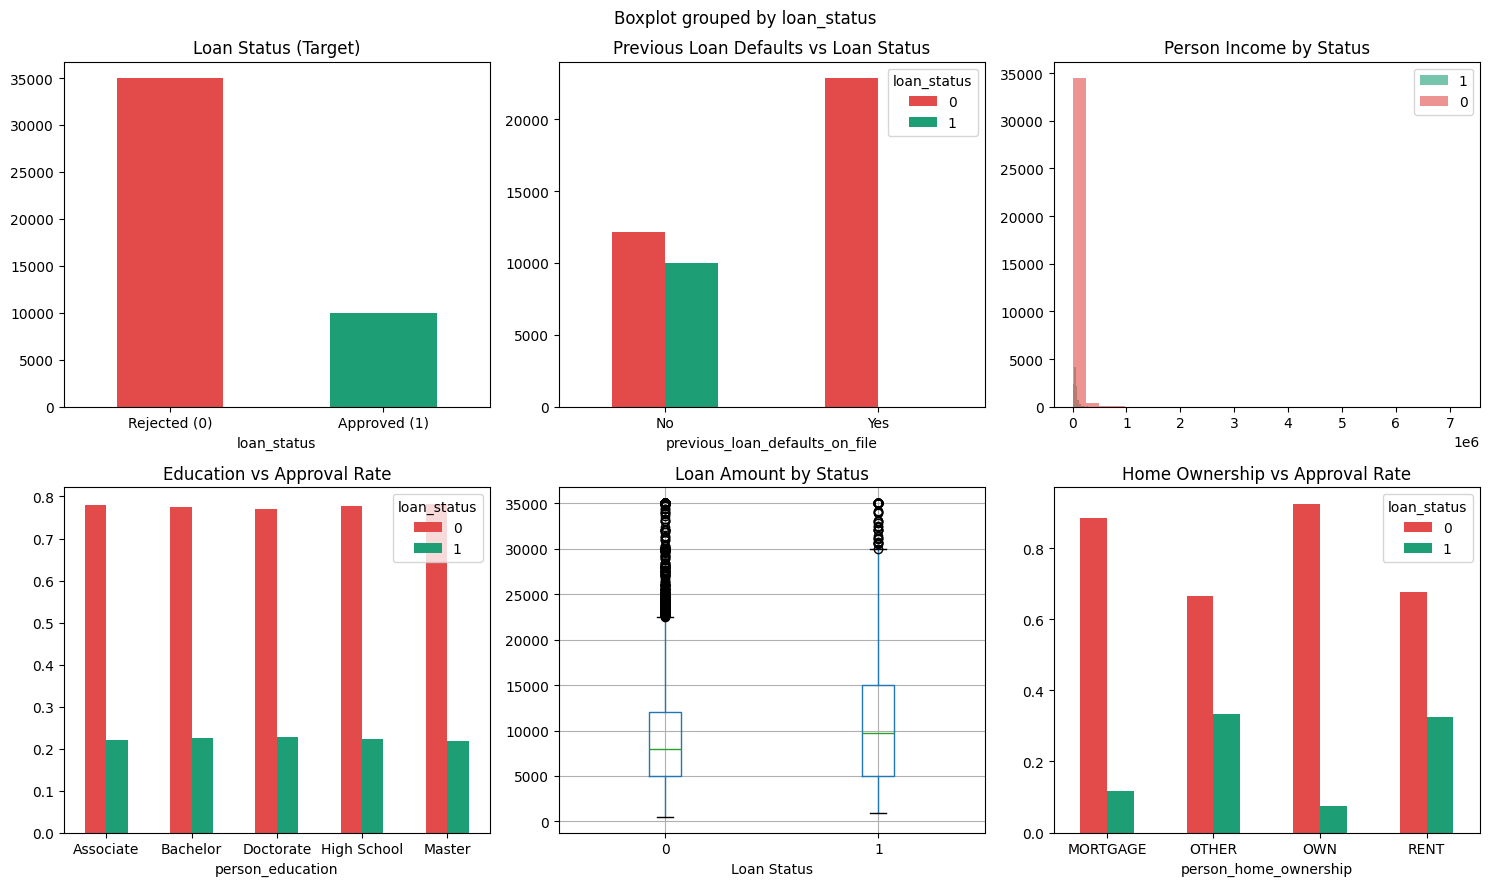

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Loan Prediction — EDA', fontsize=14, fontweight='bold')
GREEN, RED = '#1D9E75', '#E24B4A'

df['loan_status'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=[RED, GREEN],
    title='Loan Status (Target)')
axes[0,0].set_xticklabels(['Rejected (0)', 'Approved (1)'], rotation=0)

pd.crosstab(df['previous_loan_defaults_on_file'], df['loan_status']).plot(
    kind='bar', ax=axes[0,1], color=[RED, GREEN],
    title='Previous Loan Defaults vs Loan Status', rot=0)

for status, color in [(1, GREEN), (0, RED)]: # 1 for Approved (GREEN), 0 for Rejected (RED)
    subset = df[df['loan_status'] == status]['person_income']
    axes[0,2].hist(subset, bins=30, alpha=0.6, color=color, label=status)
axes[0,2].set_title('Person Income by Status')
axes[0,2].legend()

pd.crosstab(df['person_education'], df['loan_status'],
    normalize='index').plot(
    kind='bar', ax=axes[1,0], color=[RED, GREEN],
    title='Education vs Approval Rate', rot=0)

df.boxplot(column='loan_amnt', by='loan_status', ax=axes[1,1])
axes[1,1].set_title('Loan Amount by Status')
axes[1,1].set_xlabel('Loan Status')

pd.crosstab(df['person_home_ownership'], df['loan_status'],
    normalize='index').plot(
    kind='bar', ax=axes[1,2], color=[RED, GREEN],
    title='Home Ownership vs Approval Rate', rot=0)

plt.tight_layout()
plt.show()

In [6]:
data = df.copy()
print("Missing values after cleaning (current dataset has no NaNs):")
print(data.isnull().sum().sum(), "total NaNs")

Missing values after cleaning (current dataset has no NaNs):
0 total NaNs


In [7]:
data['TotalIncome'] = data['person_income']
data['Loan_to_Income'] = data['loan_amnt'] / (data['TotalIncome'] + 1)
data['Log_TotalIncome'] = np.log1p(data['TotalIncome'])
data['Log_LoanAmount']  = np.log1p(data['loan_amnt'])
print("New features: TotalIncome, Loan_to_Income,"
      " Log_TotalIncome, Log_LoanAmount")
data.head(3)

New features: TotalIncome, Loan_to_Income, Log_TotalIncome, Log_LoanAmount


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,TotalIncome,Loan_to_Income,Log_TotalIncome,Log_LoanAmount
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1,71948.0,0.486456,11.183713,10.463132
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0,12282.0,0.081413,9.415971,6.908755
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1,12438.0,0.442158,9.428592,8.612685


In [9]:
X = data.drop(columns=['loan_status'])
y = data['loan_status']                     # 0 = Rejected, 1 = Approved

# Identify categorical columns
binary_cols = ['person_gender', 'previous_loan_defaults_on_file']
nominal_cols = ['person_education', 'person_home_ownership', 'loan_intent']

# Apply Label Encoding for binary columns
for col in binary_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Apply One-Hot Encoding for nominal columns
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True) # drop_first to avoid multicollinearity

print(f"Features: {X.shape[1]} | Samples: {X.shape[0]}")
print(f"Target balance:\n{y.value_counts()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit+transform on train
X_test_sc  = scaler.transform(X_test)        # only transform on test!

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

Features: 26 | Samples: 45000
Target balance:
loan_status
0    35000
1    10000
Name: count, dtype: int64

Train: (36000, 26) | Test: (9000, 26)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(
                               n_estimators=100, max_depth=6,
                               random_state=42),
}

trained  = {}
preds    = {}

for name, model in models.items():
    Xtr = X_train_sc if name == "Logistic Regression" else X_train
    Xte = X_test_sc  if name == "Logistic Regression" else X_test

    model.fit(Xtr, y_train)
    preds[name] = {
        'y_pred': model.predict(Xte),
        'y_prob': model.predict_proba(Xte)[:, 1],
    }
    trained[name] = model

    cv = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy')
    print(f"✓ {name:22s} | CV Acc: {cv.mean():.4f} ± {cv.std():.4f}")

✓ Logistic Regression    | CV Acc: 0.8987 ± 0.0049
✓ Decision Tree          | CV Acc: 0.9130 ± 0.0034
✓ Random Forest          | CV Acc: 0.9153 ± 0.0016


In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(
                               n_estimators=100, max_depth=6,
                               random_state=42),
}

trained  = {}
preds    = {}

for name, model in models.items():
    Xtr = X_train_sc if name == "Logistic Regression" else X_train
    Xte = X_test_sc  if name == "Logistic Regression" else X_test

    model.fit(Xtr, y_train)
    preds[name] = {
        'y_pred': model.predict(Xte),
        'y_prob': model.predict_proba(Xte)[:, 1],
    }
    trained[name] = model

    cv = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy')
    print(f"✓ {name:22s} | CV Acc: {cv.mean():.4f} ± {cv.std():.4f}")

results = []

for name, p in preds.items():
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, p['y_pred']), 4),
        'Precision': round(precision_score(y_test, p['y_pred']), 4),
        'Recall':    round(recall_score(y_test, p['y_pred']), 4),
        'F1-Score':  round(f1_score(y_test, p['y_pred']), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, p['y_prob']), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
display(results_df.sort_values('ROC-AUC', ascending=False))

best = results_df['ROC-AUC'].idxmax()
print(f"\n🏆 Best model: {best}")

print(f"\n── Classification Report: {best} ──")
print(classification_report(
    y_test, preds[best]['y_pred'],
    target_names=['Rejected (N)', 'Approved (Y)']
))

✓ Logistic Regression    | CV Acc: 0.8987 ± 0.0049
✓ Decision Tree          | CV Acc: 0.9130 ± 0.0034
✓ Random Forest          | CV Acc: 0.9129 ± 0.0025


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.9133,0.9213,0.667,0.7738,0.9649
Logistic Regression,0.9043,0.7952,0.767,0.7809,0.9590
Decision Tree,0.9124,0.8677,0.715,0.7840,0.9531



🏆 Best model: Random Forest

── Classification Report: Random Forest ──
              precision    recall  f1-score   support

Rejected (N)       0.91      0.98      0.95      7000
Approved (Y)       0.92      0.67      0.77      2000

    accuracy                           0.91      9000
   macro avg       0.92      0.83      0.86      9000
weighted avg       0.91      0.91      0.91      9000



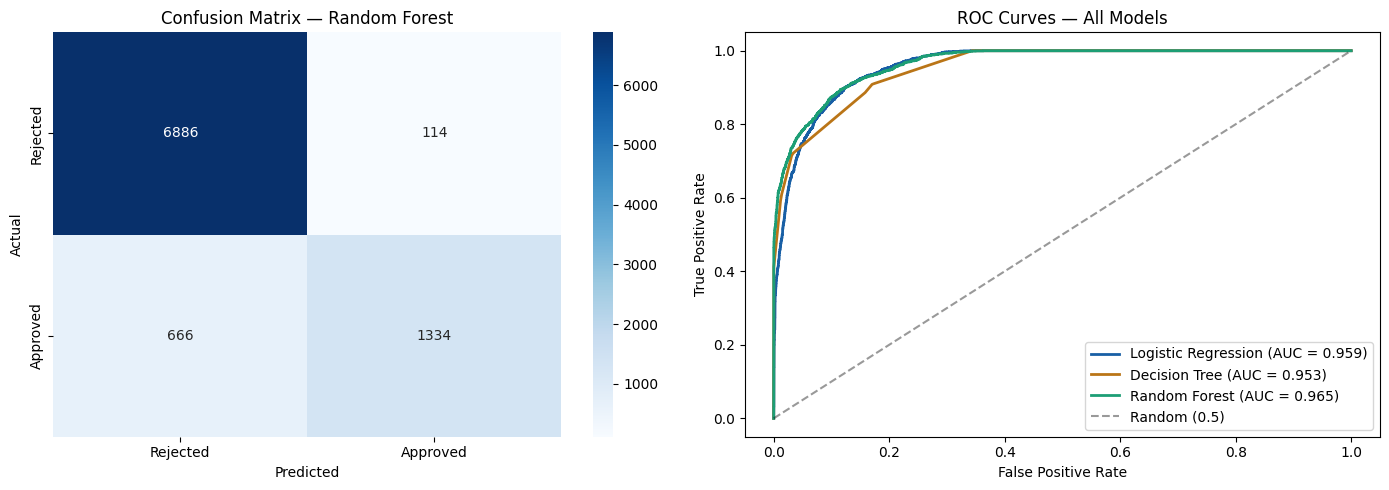

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, preds[best]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved'])
axes[0].set_title(f'Confusion Matrix — {best}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

colors = ['#185fa5', '#ba7517', '#1D9E75']
for (name, p), col in zip(preds.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, p['y_prob'])
    auc = roc_auc_score(y_test, p['y_prob'])
    axes[1].plot(fpr, tpr, color=col, lw=2,
                label=f'{name} (AUC = {auc:.3f})')

axes[1].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random (0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

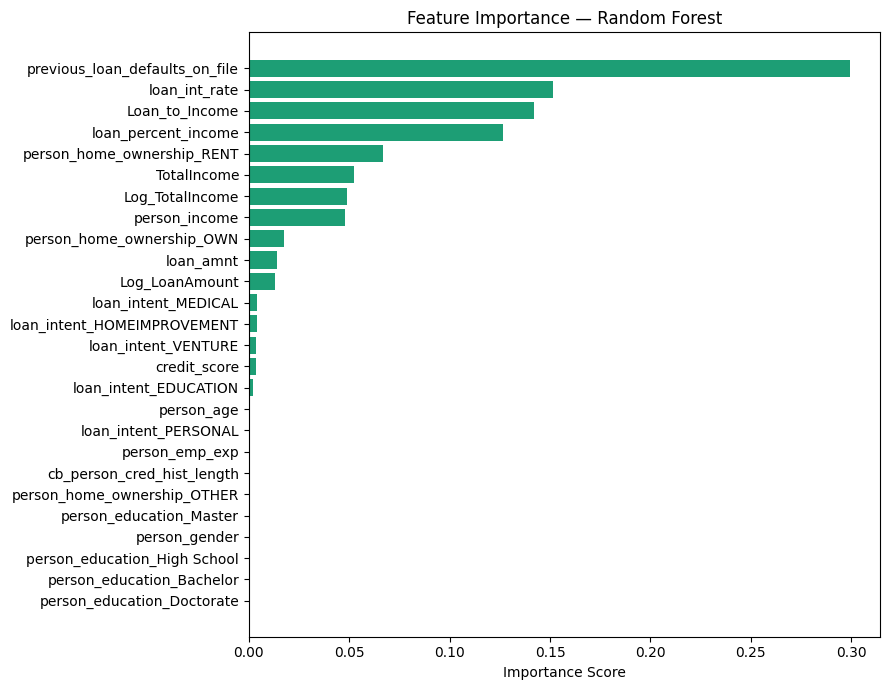


Top 5 features:
                       Feature  Importance
previous_loan_defaults_on_file    0.299347
                 loan_int_rate    0.151557
                Loan_to_Income    0.141823
           loan_percent_income    0.126639
    person_home_ownership_RENT    0.066989


In [ ]:
rf = trained["Random Forest"]

importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(importance_df['Feature'], importance_df['Importance'],
        color='#1D9E75')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(importance_df.tail(5)[::-1].to_string(index=False))

In [23]:
new_applicant = {
    'person_age':                    28,
    'person_gender':                  1,    # 1=Male, 0=Female (after encoding)
    'person_income':              55000,
    'person_emp_exp':                 3,    # years of employment
    'loan_amnt':                  10000,
    'loan_int_rate':               11.5,
    'loan_percent_income':         0.18,
    'cb_person_cred_hist_length':     4,
    'credit_score':                 680,
    'previous_loan_defaults_on_file': 0,   # 0=No, 1=Yes

    'person_education_Bachelor':      1,
    'person_education_Doctorate':     0,
    'person_education_High School':   0,
    'person_education_Master':        0,

    'person_home_ownership_OTHER':    0,
    'person_home_ownership_OWN':      0,
    'person_home_ownership_RENT':     1,

    'loan_intent_EDUCATION':          0,
    'loan_intent_HOMEIMPROVEMENT':    0,
    'loan_intent_MEDICAL':            0,
    'loan_intent_PERSONAL':           1,
    'loan_intent_VENTURE':            0,
}

new_applicant['TotalIncome']     = new_applicant['person_income']
new_applicant['Loan_to_Income']  = new_applicant['loan_amnt'] / (new_applicant['TotalIncome'] + 1)
new_applicant['Log_TotalIncome'] = np.log1p(new_applicant['TotalIncome'])
new_applicant['Log_LoanAmount']  = np.log1p(new_applicant['loan_amnt'])

input_df    = pd.DataFrame([new_applicant])[X.columns]  # keep column order
decision    = trained["Random Forest"].predict(input_df)[0]
probability = trained["Random Forest"].predict_proba(input_df)[0, 1]

label = "✅ LOAN APPROVED" if decision == 1 else "❌ LOAN REJECTED"
print(f"Decision    : {label}")
print(f"Approval %  : {probability:.1%}")

Decision    : ❌ LOAN REJECTED
Approval %  : 24.6%


In [24]:
print("Your X columns are:")
print(list(X.columns))

Your X columns are:
['person_age', 'person_gender', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'TotalIncome', 'Loan_to_Income', 'Log_TotalIncome', 'Log_LoanAmount', 'person_education_Bachelor', 'person_education_Doctorate', 'person_education_High School', 'person_education_Master', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

trained_models = {}

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc
    })

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.8773333333333333
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      7000
           1       0.74      0.69      0.72      2000

    accuracy                           0.88      9000
   macro avg       0.83      0.81      0.82      9000
weighted avg       0.87      0.88      0.88      9000


Decision Tree
Accuracy: 0.8988888888888888
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      7000
           1       0.76      0.79      0.78      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.86      0.86      9000
weighted avg       0.90      0.90      0.90      9000


Random Forest
Accuracy: 0.9377777777777778
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7000
           1       0.92      0.79      0.85      2000

    accuracy                           0.94 

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.937778
1,Decision Tree,0.898889
0,Logistic Regression,0.877333


In [ ]:
best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


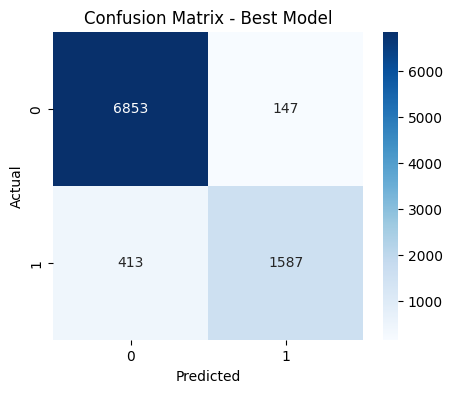

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import joblib

joblib.dump(best_model, "credit_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
new_applicant_df = pd.DataFrame([new_applicant])

prediction = best_model.predict(new_applicant_df)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Rejected


# Conclusion

*  Built a Machine Learning model for Credit Scoring
*  Compared multiple classification algorithms

*   Random Forest performed best
*   Model predicts loan approval based on financial and personal data


*   Achieved reliable classification performance










